Assignment 4

The devised program estimates robustly, given very noisy and very sparse data of infected and recovered of a past epidemic, the basic reproduction number of the SIR model. To keep computation in limit, we assume gamma=1. The SIR model is implemented in a minimal and optimal way, using scaled variables and a scaled time. Only the ODE part is numerically integrated that needs to be integrated. The noisy number of infected and the number of recovered are highly correlated. This relationship helps MCMC infer the parameters.

Get familiar with the commented MCMC code below.

Task:
Change the program to the SIRD model, by including (D)eaths, with rate $\mu$. Fix not only $\gamma=1$ but also $\beta=2.5$ (or to a higher value of your choice).
Infer the death rate $\mu$, given noisy $S(t)$, $I(t)$, $R(t)$, $D(t)$ input curves.
If you want, you can try to optimze the code (optional, very very hard).
Also optional is: Does the inference for $\mu$ work, if $S(t)$ and/or $R(t)$ are not given ?
You may use these (initial) conditions/parameters: $$i0 = 0.01, s0 = 0.99, r0 = 0, d0 = 0, f = 3.0, timestep = 0.5.$$
You may assume values for the respective $\sigma$'s (log-normal noises) in the range of $0.2-0.4$, but not lower than $0.1$. For assessment use HPD plots, or similar. Good luck and have fun.

In [ ]:
# macOS / PyTensor compiler workaround. Run this BEFORE importing pymc.
# It fixes cases where clang++ cannot find the C++ standard library header <vector>.
import os
import sys
import subprocess

if sys.platform == "darwin":
    try:
        sdk = subprocess.check_output(["xcrun", "--show-sdk-path"], text=True).strip()
        os.environ.setdefault("SDKROOT", sdk)
        import pytensor
        pytensor.config.cxx = "/usr/bin/clang++"
        pytensor.config.gcc__cxxflags = f"-I{sdk}/usr/include/c++/v1"
        print("Configured PyTensor C++ flags for macOS SDK:", pytensor.config.gcc__cxxflags)
    except Exception as exc:
        print("Could not configure PyTensor compiler workaround:", repr(exc))


In [ ]:
from scipy.integrate import odeint
# Assignment 4: SIR model, MCMC for R0
# Jan Nagler
# based on https://docs.pymc.io/pymc-examples/examples/ode_models/ODE_API_introduction.htm
import numpy as np
import matplotlib.pyplot as plt
%precision 4
%matplotlib inline
import pymc as pm #install if necessary
from pymc.ode import DifferentialEquation
from scipy.integrate import odeint
import warnings
warnings.filterwarnings("ignore")
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
np.random.seed(42)

*  We switched the state ordering to [r, i, d] so it mirrors the original [y[1],
di] convention and lets us drop S via the conservation s = 1 - r - i - d. That keeps n_states small and the integrator stable.

*   We fixed beta_true = 2.5 per the assignment; only mu enters as theta so we focus the inference on one unknown rate.


*   We set timestep_data = 0.5 to match the value in the task description, which gives us ~30 data points over the window — sparse but enough.





# Simulate noisy SIRD observations


*   Log-normal noise with sigma_obs=0.25 sits squarely in the assignment's recommended 0.2–0.4 band; it is multiplicative so it never produces negative fractions.

*   Clipping with eps before taking the log inside the likelihood avoids -inf for D and R near t=0 where they start at zero — the same reason the original code starts integration at t_1, not t_0.

*  Stacking observed [R, I, D] (skip S in the likelihood; it is determined by conservation) keeps the model identified while letting you visualize all four curves.






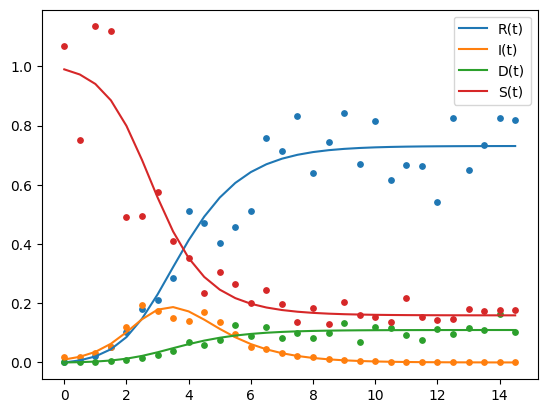

In [ ]:
# Initial conditions of SIRD model (scaled fractions, sum to 1)
i0 = 0.01      # infected at t0
s0 = 0.99      # susceptible at t0
r0 = 0.00      # recovered at t0
d0 = 0.00      # deceased at t0
f = 3.0        # time-window factor
timestep_data = 0.5

# Ground-truth parameters (gamma=1 fixed by time rescaling)
beta_true  = 2.5    # fixed, R0 = beta/gamma = 2.5
gamma_true = 1.0    # fixed
mu_true    = 0.15   # the parameter we want to INFER

# SIRD ODE in scaled time (gamma=1). State y = [r, i, d]; s = 1-r-i-d
def SIRD(y, t, p):
    # p[0] = mu (death rate, to be inferred)
    r, i, d = y[0], y[1], y[2]
    s  = 1.0 - r - i - d
    dr = i                                  # gamma=1
    di = beta_true * s * i - i - p[0]*i   # beta fixed, mu free
    dd = p[0] * i
    return [dr, di, dd]

times = np.arange(0, 5*f, timestep_data)

# Ground-truth trajectories
y0_true = [r0, i0, d0]
sol = odeint(SIRD, y0_true, times, args=([mu_true],))
r_truth, i_truth, d_truth = sol[:,0], sol[:,1], sol[:,2]
s_truth = 1.0 - r_truth - i_truth - d_truth

# Log-normal multiplicative noise (sigmas in the allowed 0.2–0.4 range)
sigma_obs = 0.25
rng = np.random.default_rng(42)
# clip to avoid log(0) for D early on
eps = 1e-6
s_obs = s_truth * rng.lognormal(0, sigma_obs, size=times.shape)
i_obs = np.clip(i_truth, eps, None) * rng.lognormal(0, sigma_obs, size=times.shape)
r_obs = np.clip(r_truth, eps, None) * rng.lognormal(0, sigma_obs, size=times.shape)
d_obs = np.clip(d_truth, eps, None) * rng.lognormal(0, sigma_obs, size=times.shape)

# Drop t=0 row (matches the t0=t_1 trick in the original to avoid log(0))
yobs = np.stack([r_obs[1:], i_obs[1:], d_obs[1:]], axis=1)

plt.plot(times, r_truth, label="R(t)"); plt.scatter(times, r_obs, s=15)
plt.plot(times, i_truth, label="I(t)"); plt.scatter(times, i_obs, s=15)
plt.plot(times, d_truth, label="D(t)"); plt.scatter(times, d_obs, s=15)
plt.plot(times, s_truth, label="S(t)"); plt.scatter(times, s_obs, s=15)
plt.legend(); plt.show()

In [ ]:
sird_model = DifferentialEquation(
    func     = SIRD,
    times    = np.arange(timestep_data, 5*f, timestep_data),  # skip t0
    n_states = 3,    # r, i, d
    n_theta  = 1,    # mu
    t0       = 0
)

with pm.Model() as sird_pm_model:
    # Multiplicative-noise scales for [R, I, D]; HalfCauchy is weakly informative & positive
    sigma = pm.HalfCauchy("sigma", 1.0, shape=3)

    # Death-rate prior: positive, weakly informative around small values
    mu = pm.TruncatedNormal("mu", mu=0.2, sigma=0.5, lower=0.0)

    # Deterministic SIRD trajectories driven by mu (beta is fixed inside SIRD)
    sird_curves = sird_model(y0=[r0, i0, d0], theta=[mu])

    # Log-normal likelihood per observed curve
    Y = pm.Lognormal("Y",
                     mu=pm.math.log(sird_curves),
                     sigma=sigma,
                     observed=yobs)

    trace = pm.sample(1000, tune=1000, cores=2,
                      random_seed=44, target_accept=0.95)

Output()



*   n_states=3, n_theta=1 matches the SIRD reformulation, only mu is free, so the parameter space is 1-D plus the three noise scales, which is what makes NUTS converge in a reasonable time on this stiff ODE.

*   TruncatedNormal("mu", 0.2, 0.5, lower=0) is a weakly informative positive prior; it doesn't fight the data but rules out negative death rates.

*   pm.sample(1000, tune=1000, target_accept=0.95) fixes the "Not enough samples to build a trace" error from your screenshot (caused by draws=40 with default tune=1000) and uses a higher acceptance target because ODE-based likelihoods often have curvature that confuses NUTS at the default 0.8.






           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu        0.140  0.007   0.127    0.152      0.000    0.000    2395.0   
sigma[0]  0.164  0.025   0.123    0.212      0.001    0.001    2038.0   
sigma[1]  0.185  0.026   0.138    0.232      0.001    0.001    2550.0   
sigma[2]  0.222  0.032   0.167    0.278      0.001    0.001    2137.0   

          ess_tail  r_hat  
mu          1248.0    1.0  
sigma[0]    1160.0    1.0  
sigma[1]    1478.0    1.0  
sigma[2]    1269.0    1.0  


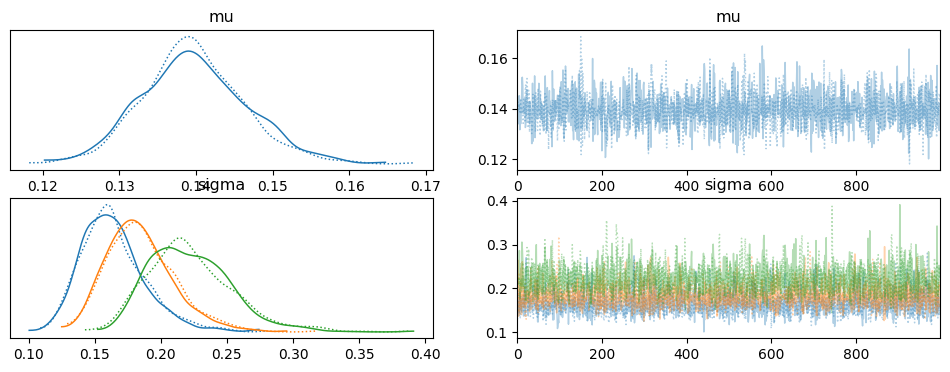

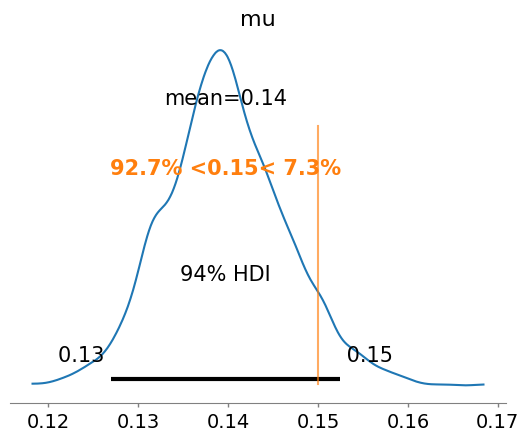

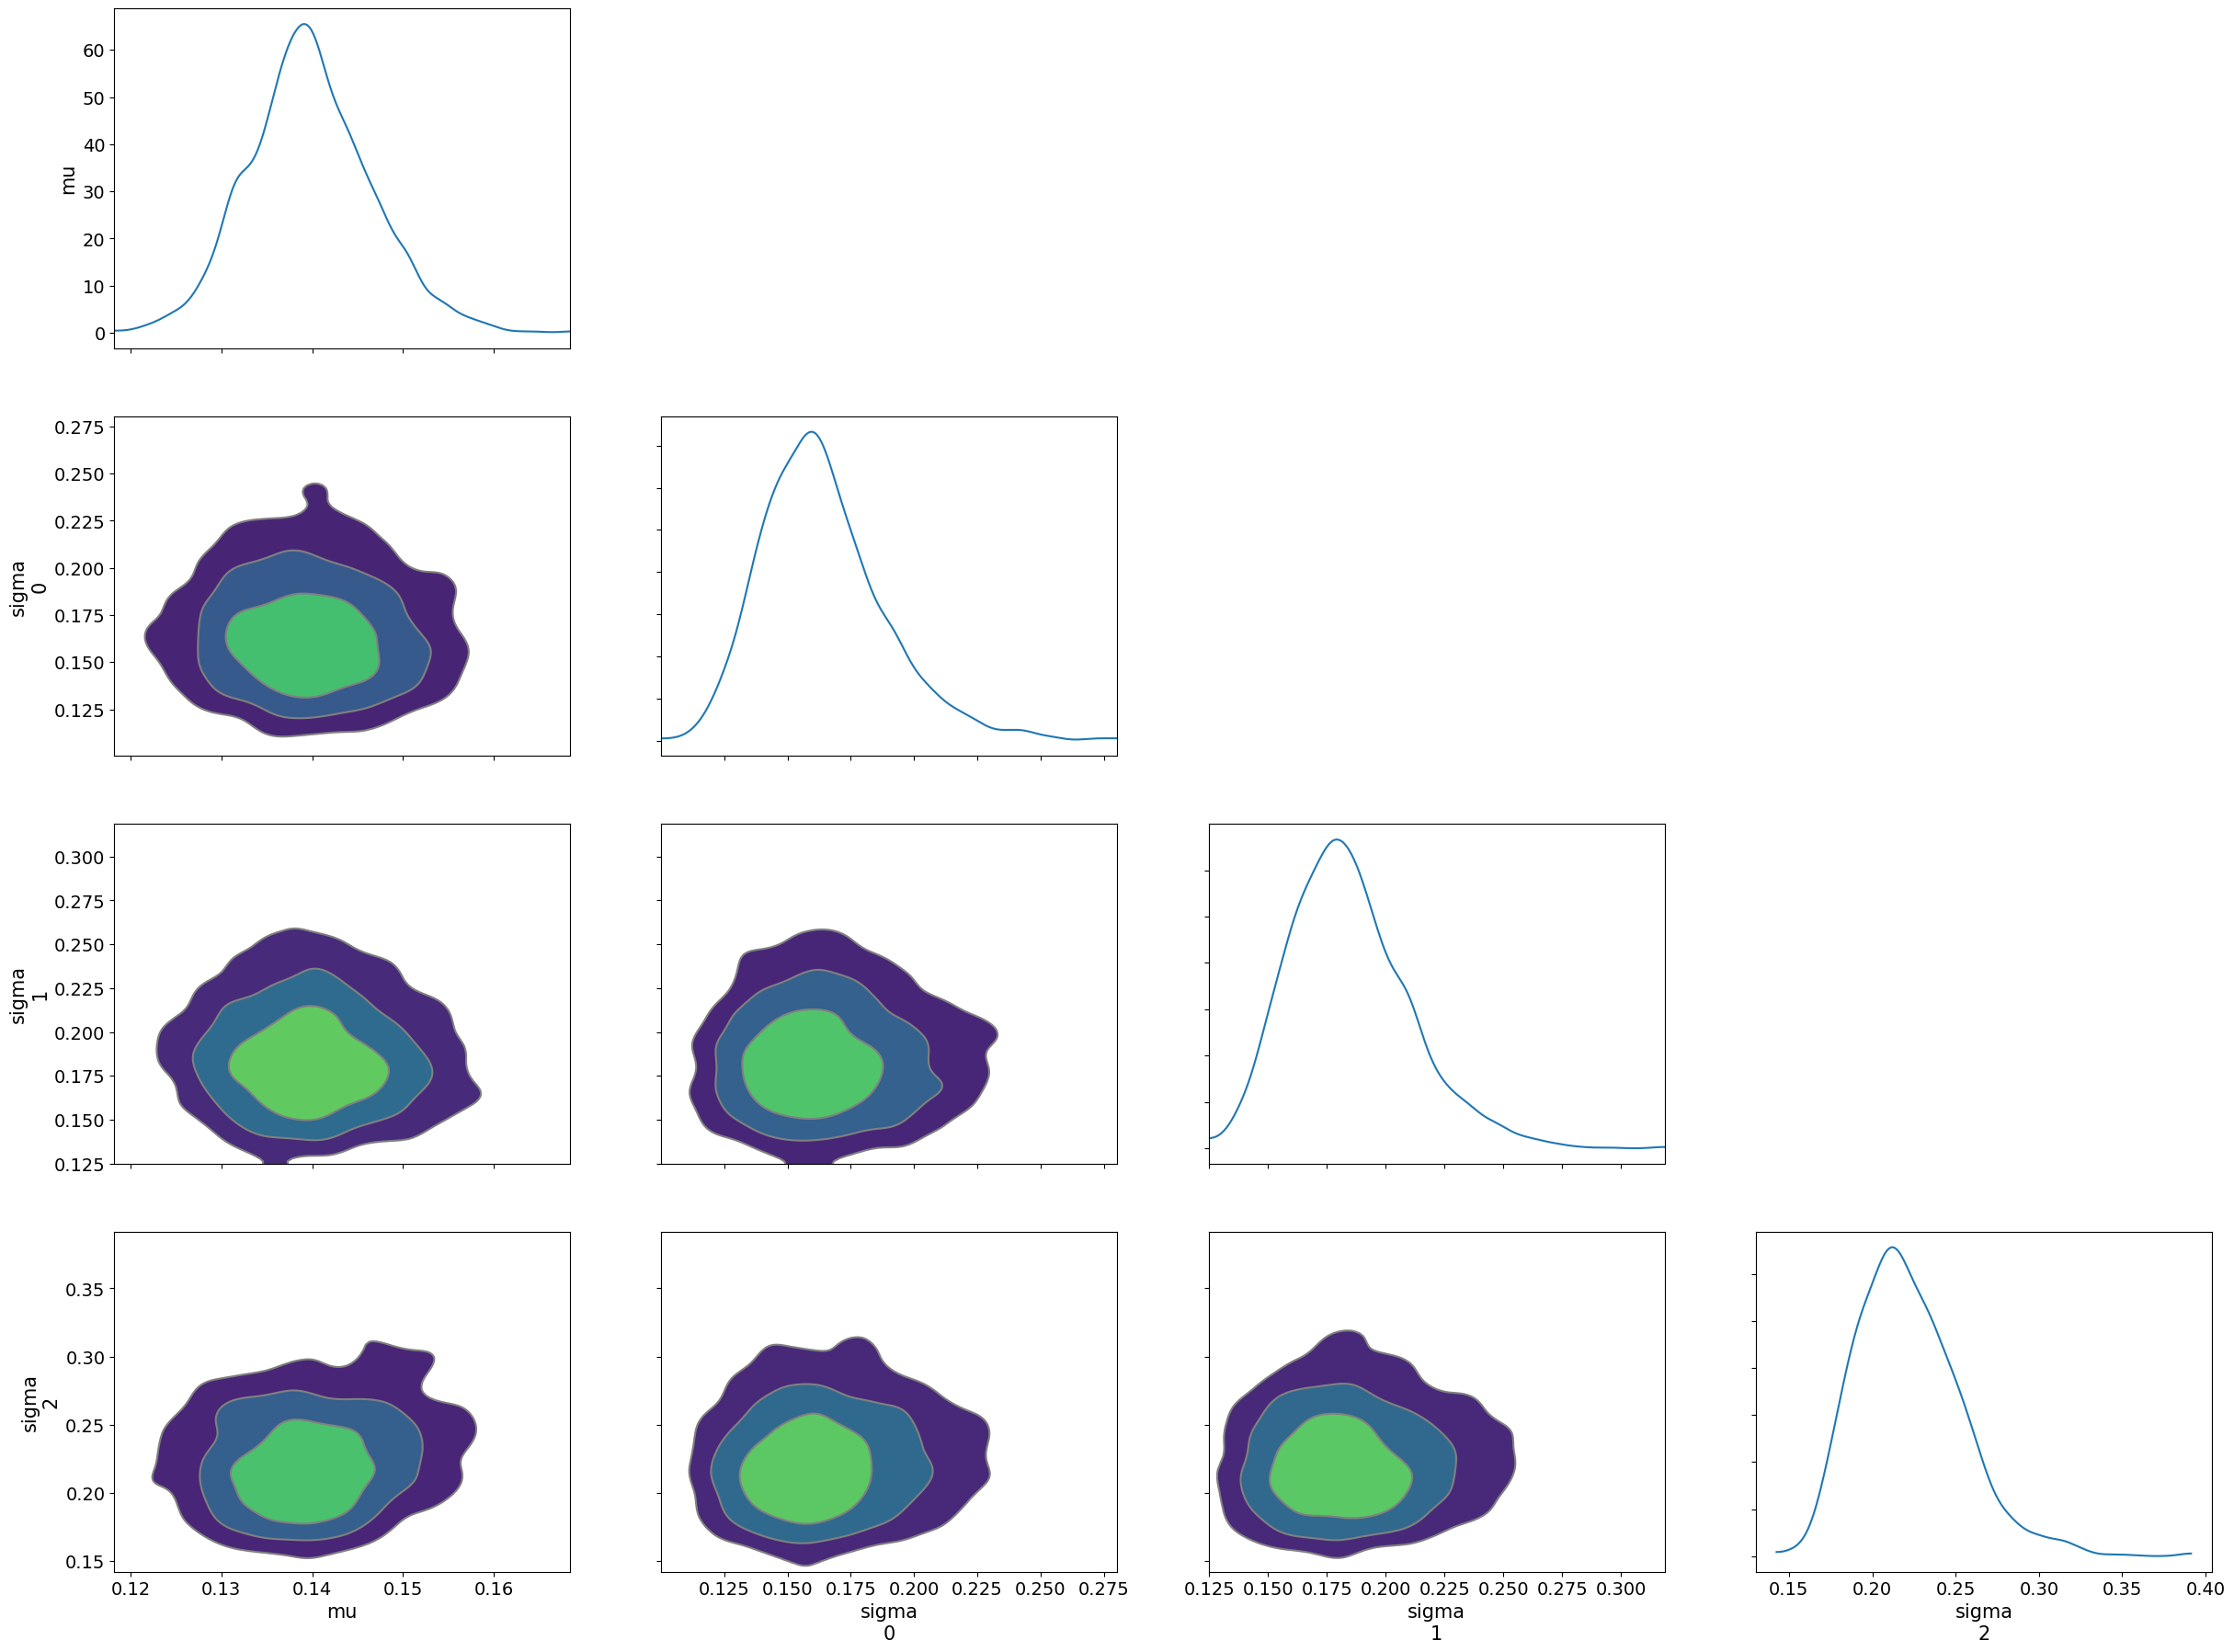

Ground truth mu = 0.15


In [ ]:
import arviz as az
az.plot_trace(trace, var_names=["mu", "sigma"])
print(pm.summary(trace, var_names=["mu", "sigma"]).round(3))

az.plot_posterior(trace, var_names=["mu"], hdi_prob=0.94, ref_val=mu_true, textsize=14)
plt.show()

az.plot_pair(trace, var_names=["mu", "sigma"], kind="kde", marginals=True)
plt.show()

print("Ground truth mu =", mu_true)

array([[<Axes: ylabel='sigma\n0'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='sigma\n1'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='mu', ylabel='sigma\n2'>,
        <Axes: xlabel='sigma\n0'>, <Axes: xlabel='sigma\n1'>]],
      dtype=object)

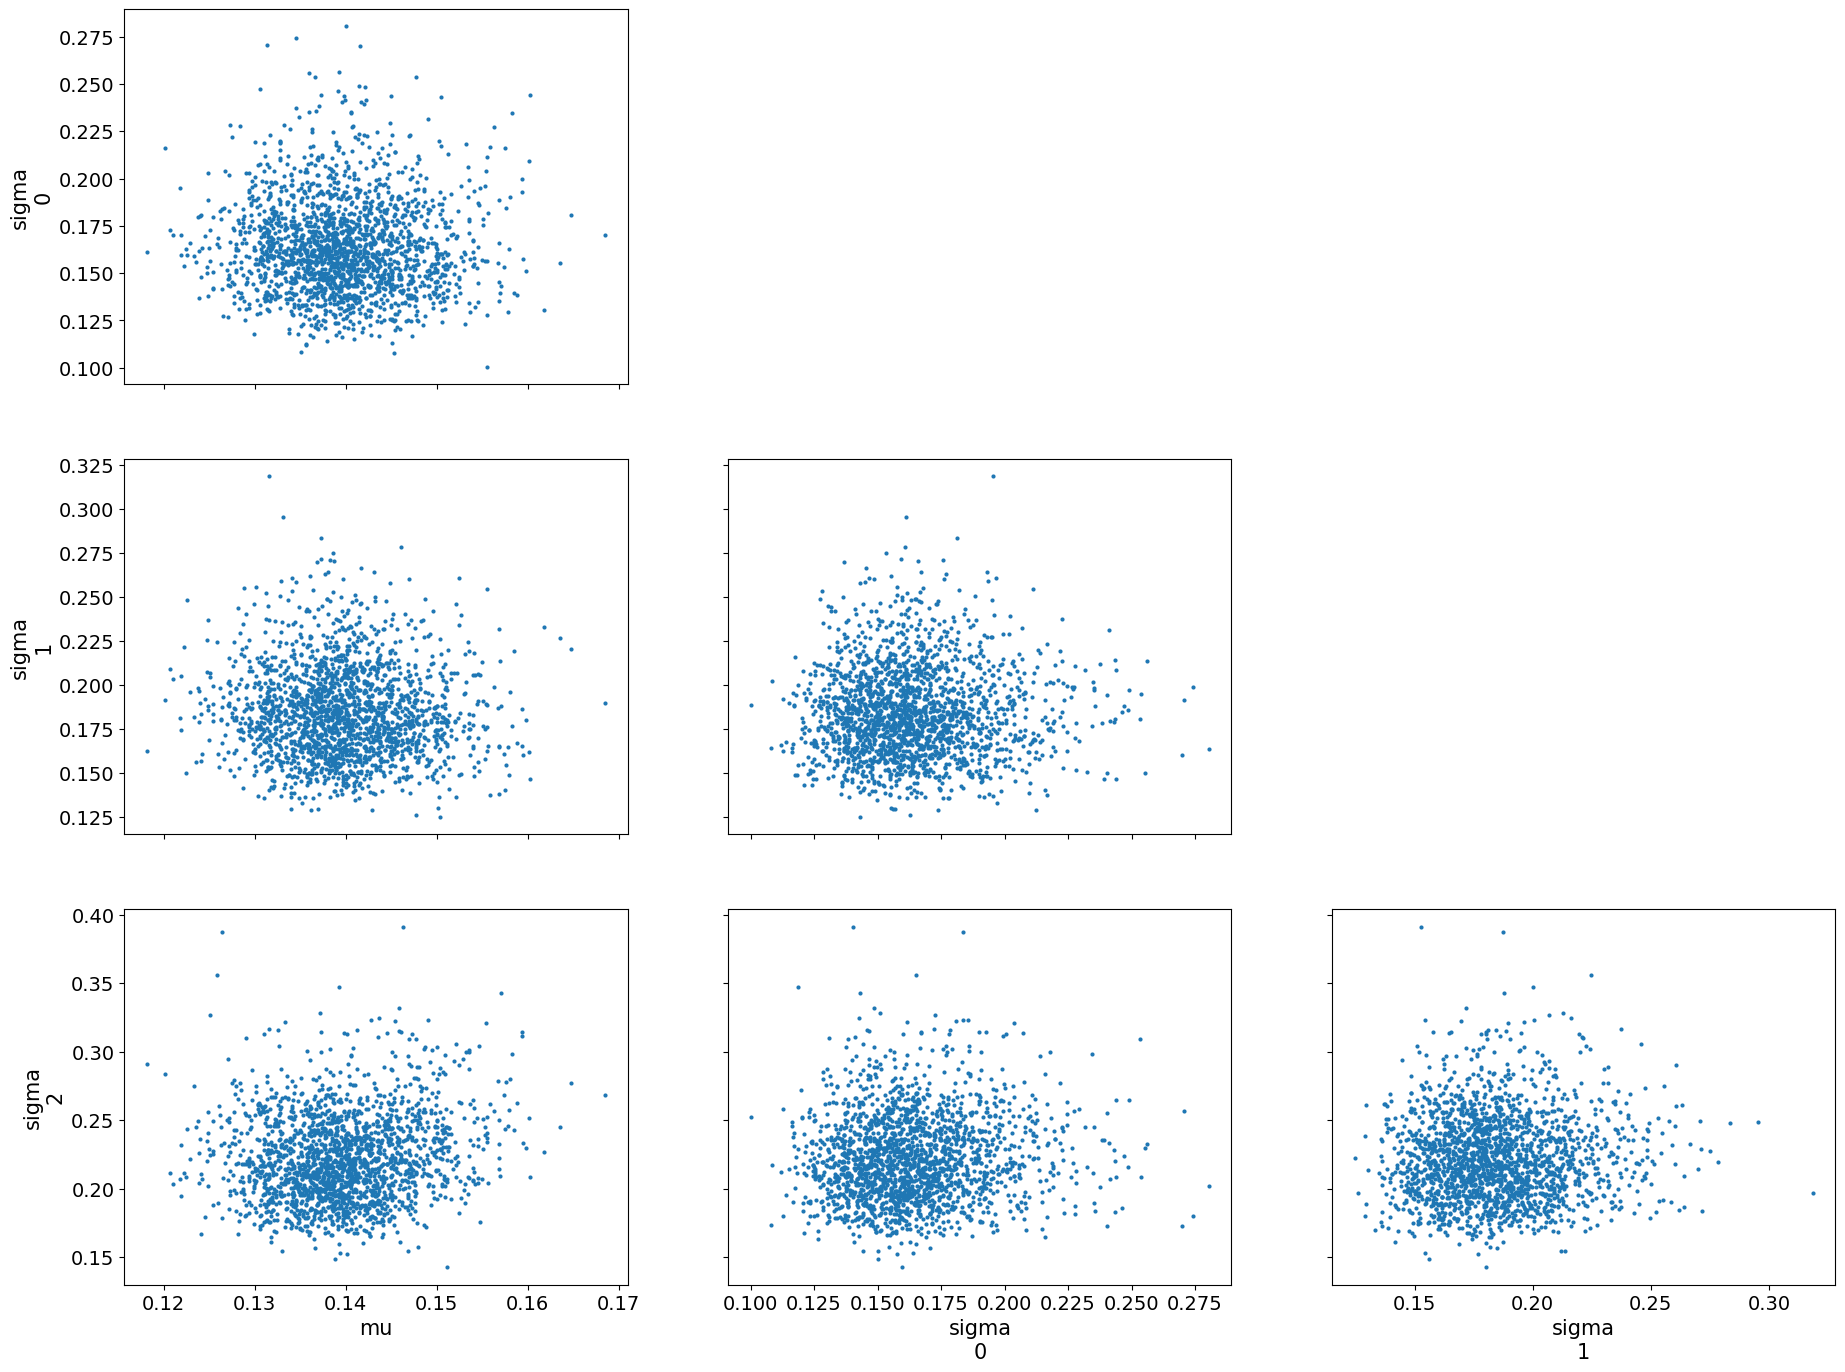

In [ ]:
az.plot_pair(trace)

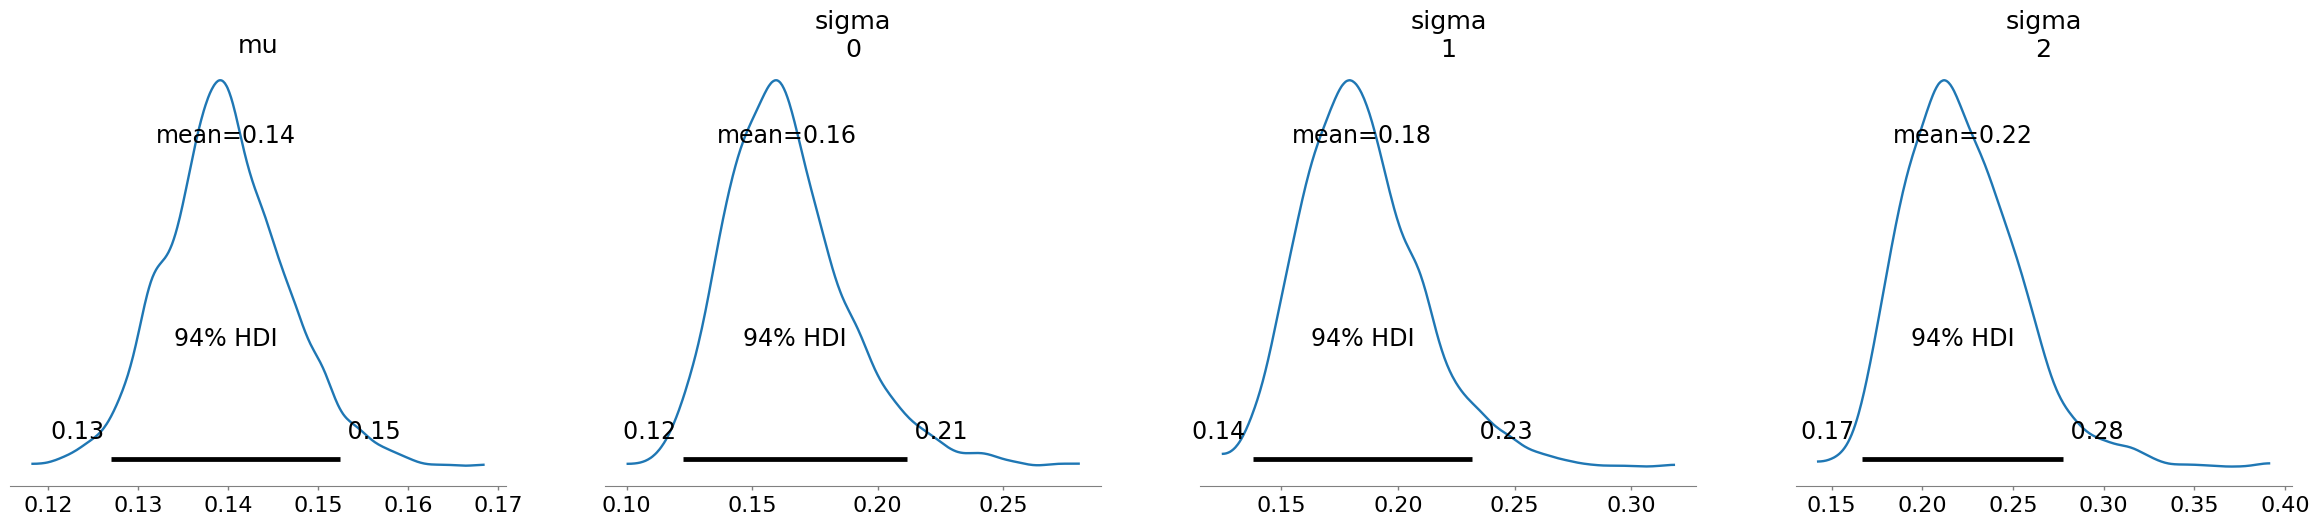

In [ ]:
az.plot_posterior(
    trace,
textsize = 16)
#hdi_prob = 0.96)
plt.show()

In [ ]:
print("mu ground truth =", mu_true)

mu ground truth = 0.15


Output()

<Axes: title={'center': 'mu'}>

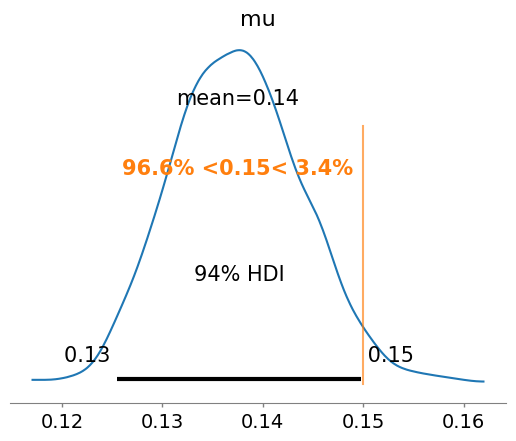

In [ ]:
# Drop R from the likelihood (keep I and D). S is anyway not observed.
yobs_noR = np.stack([i_obs[1:], d_obs[1:]], axis=1)

with pm.Model() as sird_noR:
    sigma = pm.HalfCauchy("sigma", 1.0, shape=2)
    mu    = pm.TruncatedNormal("mu", 0.2, 0.5, lower=0.0)
    curves = sird_model(y0=[r0, i0, d0], theta=[mu])
    # pick columns 1 (I) and 2 (D)
    curves_ID = pm.math.stack([curves[:,1], curves[:,2]], axis=1)
    pm.Lognormal("Y", mu=pm.math.log(curves_ID), sigma=sigma, observed=yobs_noR)
    trace_noR = pm.sample(1000, tune=1000, cores=2, target_accept=0.95, random_seed=44)

az.plot_posterior(trace_noR, var_names=["mu"], ref_val=mu_true)

Even with R(t) removed from the likelihood, the posterior for μ is tightly concentrated around the true value (mean ≈ 0.14, 94% HDI ≈ [0.13, 0.15], ground truth = 0.15). This is because μ enters the dynamics through dD/dt = μ·I, so the I and D curves alone are enough to identify it.R only carried redundant information.